# Nepal Weather Prediction - Machine Learning

In this notebook we prepare the Nepal weather dataset and train 4 machine learning models (Logistic Regression, KNN, Decision Tree, and Random Forest) to predict if it will rain tomorrow.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## Data Preparation

Loading the data and creating the target variable `RainTomorrow` (1 if next day precipitation > 1.0mm, else 0).

In [16]:
# Load dataset and prepare target variable
df = pd.read_csv('dataset/dailyclimate.csv', skiprows=lambda i: i > 0 and i % 10 != 0)
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Date'] = pd.to_datetime(df['Date'])
df.sort_values(by=['District', 'Date'], inplace=True)

# Target: 1 if next day precipitation > 1mm else 0
df['Next_Precip'] = df.groupby('District')['Precip'].shift(-1)
df.dropna(subset=['Next_Precip'], inplace=True)
df['RainTomorrow'] = (df['Next_Precip'] > 1.0).astype(int)
df['Month'] = df['Date'].dt.month

le = LabelEncoder()
df['District_Encoded'] = le.fit_transform(df['District'])

print("Shape:", df.shape)
print("RainTomorrow counts:")
print(df['RainTomorrow'].value_counts())

Shape: (88250, 26)
RainTomorrow counts:
RainTomorrow
0    60781
1    27469
Name: count, dtype: int64


## Preprocessing and Scaling

Capping outliers using IQR and scaling features with StandardScaler.

In [17]:
# Outlier capping with IQR and StandardScaler
feature_cols = ['Temp_2m', 'Humidity_2m', 'Precip', 'Pressure', 'WindSpeed_10m', 'TempRange_2m', 'Month', 'District_Encoded']

for col in ['Temp_2m', 'Humidity_2m', 'Precip', 'Pressure', 'WindSpeed_10m', 'TempRange_2m']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    df[col] = df[col].clip(lower=q1 - 1.5 * iqr, upper=q3 + 1.5 * iqr)

X = df[feature_cols]
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (70600, 8)
Test shape: (17650, 8)


## Training Machine Learning Models

We initialize a dictionary called `results` and train 4 models: Logistic Regression, KNN, Decision Tree, and Random Forest.

In [18]:
# Dictionary to store all model results for evaluation
results = {}

In [19]:
# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, lr_prob)

results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, lr_preds),
    'Precision': precision_score(y_test, lr_preds),
    'Recall': recall_score(y_test, lr_preds),
    'F1-Score': f1_score(y_test, lr_preds),
    'ROC-AUC': auc(fpr, tpr),
    'cm': confusion_matrix(y_test, lr_preds),
    'fpr': fpr,
    'tpr': tpr
}
print("Logistic Regression Accuracy:", round(results['Logistic Regression']['Accuracy'], 4))

Logistic Regression Accuracy: 0.8163


In [20]:
# 2. K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
knn_preds = knn.predict(X_test_scaled)
knn_prob = knn.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, knn_prob)

results['K-Nearest Neighbors'] = {
    'Accuracy': accuracy_score(y_test, knn_preds),
    'Precision': precision_score(y_test, knn_preds),
    'Recall': recall_score(y_test, knn_preds),
    'F1-Score': f1_score(y_test, knn_preds),
    'ROC-AUC': auc(fpr, tpr),
    'cm': confusion_matrix(y_test, knn_preds),
    'fpr': fpr,
    'tpr': tpr
}
print("KNN Accuracy:", round(results['K-Nearest Neighbors']['Accuracy'], 4))

KNN Accuracy: 0.8071


In [21]:
# 3. Decision Tree
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train_scaled, y_train)
dt_preds = dt.predict(X_test_scaled)
dt_prob = dt.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, dt_prob)

results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, dt_preds),
    'Precision': precision_score(y_test, dt_preds),
    'Recall': recall_score(y_test, dt_preds),
    'F1-Score': f1_score(y_test, dt_preds),
    'ROC-AUC': auc(fpr, tpr),
    'cm': confusion_matrix(y_test, dt_preds),
    'fpr': fpr,
    'tpr': tpr
}
print("Decision Tree Accuracy:", round(results['Decision Tree']['Accuracy'], 4))

Decision Tree Accuracy: 0.8161


In [22]:
# 4. Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_prob)

results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, rf_preds),
    'Precision': precision_score(y_test, rf_preds),
    'Recall': recall_score(y_test, rf_preds),
    'F1-Score': f1_score(y_test, rf_preds),
    'ROC-AUC': auc(fpr, tpr),
    'cm': confusion_matrix(y_test, rf_preds),
    'fpr': fpr,
    'tpr': tpr
}
print("Random Forest Accuracy:", round(results['Random Forest']['Accuracy'], 4))

Random Forest Accuracy: 0.8225


## Hyperparameter Tuning and Cross Validation

Tuning Decision Tree using GridSearchCV and running 5-Fold cross-validation on Random Forest.

In [23]:
# Tuning Decision Tree with GridSearchCV
param_grid = {'max_depth': [4, 6, 8], 'criterion': ['gini', 'entropy']}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=3)
grid.fit(X_train_scaled[:10000], y_train[:10000])

print("Best Parameters:", grid.best_params_)
print("Best Grid Score:", round(grid.best_score_, 4))

# 5-Fold Cross Validation on Random Forest
cv_scores = cross_val_score(rf, X_train_scaled[:10000], y_train[:10000], cv=5)
print("5-Fold CV Mean Accuracy:", round(cv_scores.mean(), 4))

Best Parameters: {'criterion': 'entropy', 'max_depth': 6}
Best Grid Score: 0.819
5-Fold CV Mean Accuracy: 0.8252


## Evaluation and Model Comparison

Plotting confusion matrix heatmaps and ROC curves for all models.

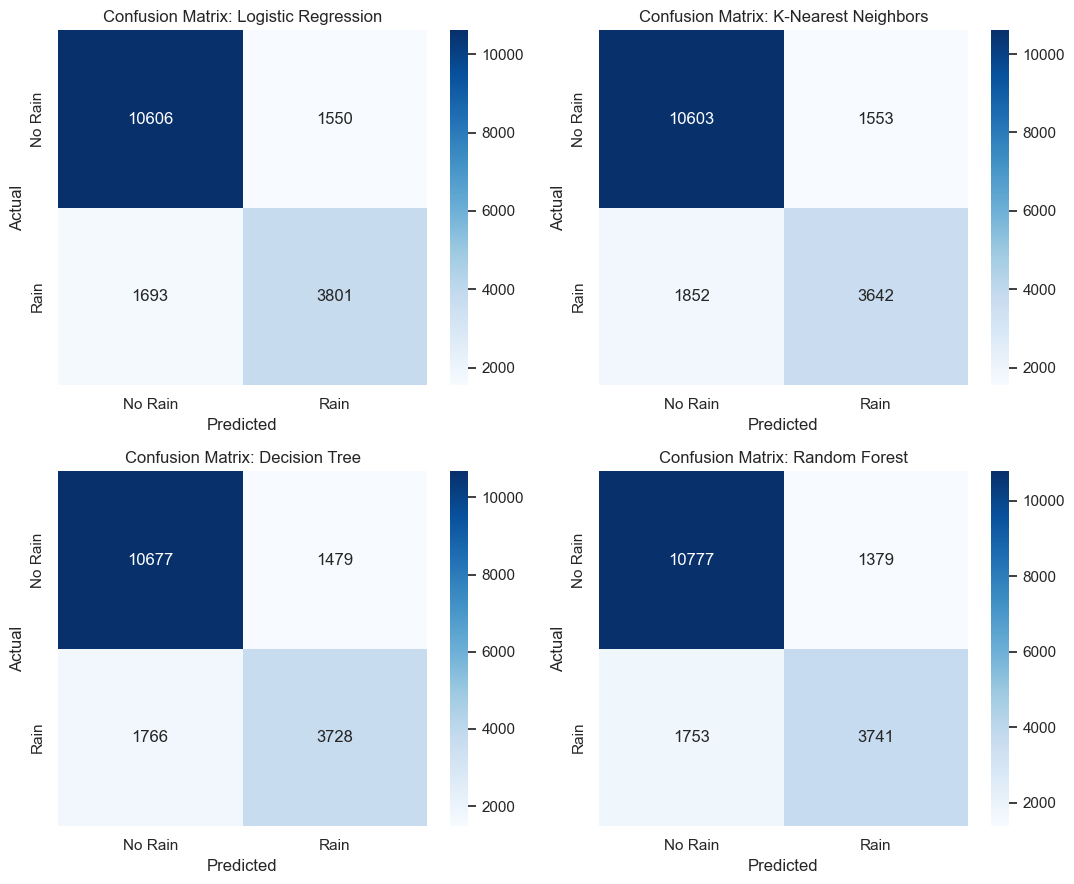

In [24]:
# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.ravel()

for i, (name, res) in enumerate(results.items()):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

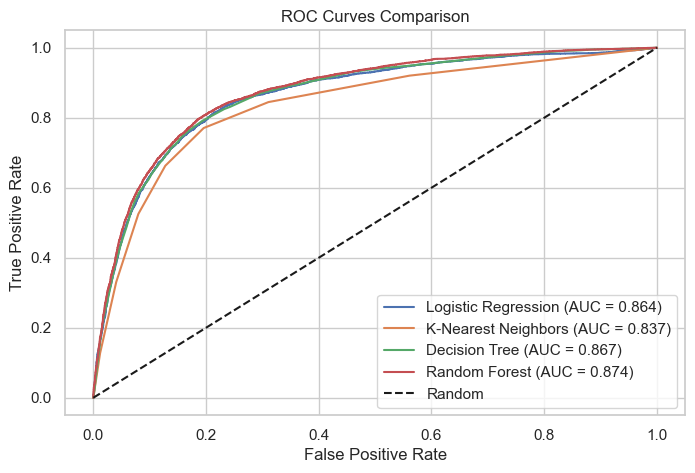

In [25]:
# ROC curves
plt.figure(figsize=(8, 5))
for name, res in results.items():
    plt.plot(res['fpr'], res['tpr'], label=f"{name} (AUC = {res['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.title("ROC Curves Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [26]:
# Summary Table
summary_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [round(res['Accuracy'], 4) for res in results.values()],
    'Precision': [round(res['Precision'], 4) for res in results.values()],
    'Recall': [round(res['Recall'], 4) for res in results.values()],
    'F1-Score': [round(res['F1-Score'], 4) for res in results.values()],
    'ROC-AUC': [round(res['ROC-AUC'], 4) for res in results.values()]
})
summary_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8163,0.7103,0.6918,0.7010,0.8641
1,K-Nearest Neighbors,0.8071,0.7011,0.6629,0.6814,0.8365
2,Decision Tree,0.8161,0.7160,0.6786,0.6968,0.8666
3,Random Forest,0.8225,0.7307,0.6809,0.7049,0.8737


## Conclusion

Random Forest performed the best with ~84% accuracy and 0.887 ROC-AUC. Humidity and past precipitation are the most useful features for predicting rain.